# 缩放定律与算力预算

> MoE 把总参数量与单 Token 计算量分开，但任何架构最终都要在参数、数据和算力之间分配预算。Chinchilla 只有 70B 参数，Gopher 有 280B 参数；两者训练算力接近，使用更多数据的 Chinchilla 却取得了更好的结果。固定预算下，**参数与数据的配比**比单独增大模型更重要。
>
> 这一章建立三本相互关联的账：
>
> **效果账**记录参数量 $N$、数据量 $D$ 与 loss 的幂律关系。
>
> **计算账**用 $C \approx 6ND$ 把训练方案换算为 FLOPs 和 GPU-hours。
>
> **显存账**核算参数、优化器与激活值能否放入显存。
>
> Kaplan、Chinchilla 与 LLaMA 给出了不同的预算分配方式，µP 则回答小模型上调好的超参数如何迁移到大模型。把这些结论放在同一张账本中，才能判断一个训练方案是否同时满足效果、算力与硬件约束。

扩大训练规模有两种直接做法：增加模型参数量 $N$，或者让模型读取更多 Token，也就是增加数据量 $D$。两者都会消耗算力，而训练计算量可以近似写成 $C \approx 6ND$。

当计算预算 $C$ 固定时，增大 $N$ 就意味着能够使用的 $D$ 减少；增加数据也会反过来限制模型规模。问题因此不再是「模型是否越大越好」，而是参数与数据应该按照什么比例增长。

**Scaling Laws** 用经验曲线描述 $N$、$D$、$C$ 与 loss 的关系。下面先从收益递减的幂律曲线开始，再比较 Kaplan、Chinchilla 与 LLaMA 给出的预算分配方式。

## 1. 幂律与收益递减

先建立一个直觉。假设你在背英语单词，粗略的量级是这样的：

- 背最常见的 100 个词，日常文本能看懂一半；
- 背到 1,000 个，能看懂七成半；
- 背到 10,000 个，九成；
- 背到 100,000 个，提升就更小了。

每花十倍的力气，换来的提升都比上一轮少。这不是你不够努力，而是词频本身服从幂律（Zipf 定律）：少数词出现得极多，长尾的词出现得极少，多背一个新词的期望收益自然越来越小。

LLM 的训练 loss 也是这样。把「词汇量」换成「模型参数量 N」，经验规律可以写成：

$$\text{Loss}(N) \approx a \cdot N^{-b} + c$$

三个常数各有含义：

- a：整体缩放，把曲线抬到合适的高度；
- b：衰减速度，决定每扩大多少倍换来多少 loss；
- c：loss 的地板。文本本身有不可预测的部分，无论模型多大，loss 都压不进 c。

真正重要的是 $N^{-b}$ 的形状：N 每乘以 10，loss 的「可约部分」（Loss - c）就乘以固定系数 $10^{-b}$，一个小于 1 的数。收益递减不是感觉，是被写进了公式里。

Loss = 5.0 × N^(-0.05) + 2.0
  size    loss  reducible  vs prev
------------------------------------
    1M   4.506      2.506       —
   10M   4.233      2.233    89.1%
  100M   3.991      1.991    89.1%
    1B   3.774      1.774    89.1%
   10B   3.581      1.581    89.1%
  100B   3.409      1.409    89.1%

关键观察：每扩大 10 倍，可约部分固定缩到 10^(-0.05) ≈ 89.1%
          loss 从 4.5 走到 3.4：后面几档，扩大 10 倍只换来 0.2 左右


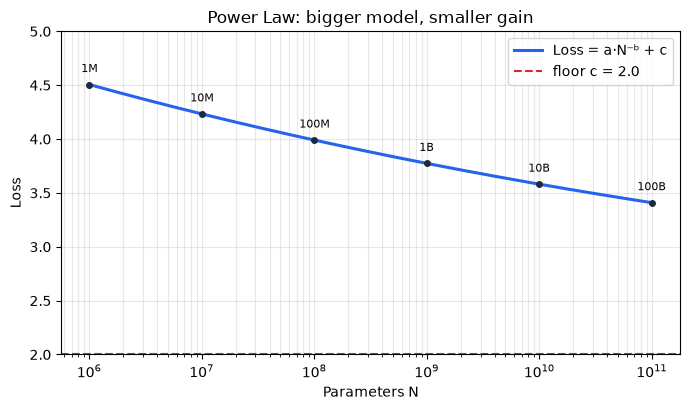

In [1]:
# === 幂律手算 + 可视化：模型每扩大 10 倍，loss 降多少 ===
a, b, c = 5.0, 0.05, 2.0   # 演示用的拟合常数

# 先用具体数字手算一遍，看清每次扩大 10 倍 loss 降多少
sizes = [1, 10, 100, 1000, 10000, 100000]   # 单位：百万参数
labels = ["1M", "10M", "100M", "1B", "10B", "100B"]

print(f"Loss = {a} × N^(-{b}) + {c}")
print(f"{'size':>6s} {'loss':>7s} {'reducible':>10s} {'vs prev':>8s}")
print("-" * 36)
prev = None
for s, lab in zip(sizes, labels):
    N = s * 1e6
    loss = a * N ** (-b) + c
    gap = loss - c                          # 可约部分 = Loss - c
    if prev:
        print(f"{lab:>6s} {loss:>7.3f} {gap:>10.3f} {gap/prev*100:>7.1f}%")
    else:
        print(f"{lab:>6s} {loss:>7.3f} {gap:>10.3f}       —")
    prev = gap

print()
print("关键观察：每扩大 10 倍，可约部分固定缩到 10^(-0.05) ≈ 89.1%")
print("          loss 从 4.5 走到 3.4：后面几档，扩大 10 倍只换来 0.2 左右")

# 再画成曲线，直观感受「越大越不值」
import matplotlib.pyplot as plt
import numpy as np

N_range = np.logspace(6, 11, 300)
loss_range = a * N_range ** (-b) + c

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(N_range, loss_range, color='#2563eb', linewidth=2.2, label='Loss = a·N⁻ᵇ + c')
ax.axhline(c, color='#dc2626', linestyle='--', linewidth=1.5, label=f'floor c = {c}')

# 标注手算过的离散点
for s, lab in zip(sizes, labels):
    N = s * 1e6
    loss = a * N ** (-b) + c
    ax.plot(N, loss, 'o', color='#1e293b', markersize=4)
    ax.annotate(lab, (N, loss), textcoords="offset points", xytext=(0, 9),
                fontsize=8, ha='center')

ax.set_xscale('log')
ax.set_xlabel('Parameters N')
ax.set_ylabel('Loss')
ax.set_title('Power Law: bigger model, smaller gain')
ax.legend(loc='upper right')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(2.0, 5.0)
plt.tight_layout()
plt.show()

## 2. Kaplan Scaling Laws

公式有了，下一个问题更实际：训练预算固定（比如 $10^{21}$ FLOPs），模型多大、数据多少，loss 才最低？

OpenAI 的 Kaplan et al.（2020）用一批从 1M 到 1B 参数的模型做了大量训练实验，拟合出「计算最优」的配比：

```
N_opt ∝ C^0.73    ← 模型大小随预算增长快
D_opt ∝ C^0.27    ← 数据量随预算增长慢
```

指数 0.73 远大于 0.27。翻译成人话：预算翻倍时，多出来的钱大部分应该拿来加大模型，数据只加一点。每翻一次倍：

- 模型乘以 $2^{0.73} \approx 1.66$ 倍
- 数据乘以 $2^{0.27} \approx 1.21$ 倍

照这个配方训出来的代表作品就是 GPT-3：175B 参数，只配了 300B tokens，每个参数才见 1.7 个 token。

参照点: N=1B, D=20B tokens (C≈1.2e+20 FLOPs)

     预算    模型 (×0.73)    数据 (×0.27)     D/N
----------------------------------------------
     1×       1.0B      20.0B   20.0x
     2×       1.7B      24.1B   14.5x
     4×       2.8B      29.1B   10.6x
     8×       4.6B      35.1B    7.7x
    10×       5.4B      37.2B    6.9x
   100×      28.8B      69.3B    2.4x

关键观察：
  1. 预算涨 100 倍：模型涨 100^0.73 ≈ 29 倍，数据只涨 100^0.27 ≈ 3.5 倍
  2. D/N 一路下滑：Kaplan 的世界观里，大模型天生「省数据」


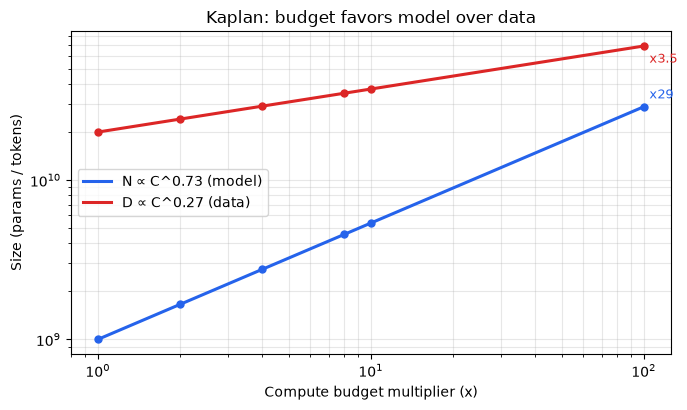

In [2]:
# === Kaplan 手算 + 可视化：预算翻倍，模型和数据各长多快 ===
N_ref, D_ref = 1e9, 20e9          # 参照点：C = 6ND ≈ 1.2e20 时 N=1B、D=20B
C_ref = 6 * N_ref * D_ref

print(f"参照点: N={N_ref/1e9:.0f}B, D={D_ref/1e9:.0f}B tokens (C≈{C_ref:.1e} FLOPs)")
print()
print(f"{'预算':>7s} {'模型 (×0.73)':>13s} {'数据 (×0.27)':>13s} {'D/N':>7s}")
print("-" * 46)

mults = [1, 2, 4, 8, 10, 100]
Ns = [N_ref * m ** 0.73 for m in mults]
Ds = [D_ref * m ** 0.27 for m in mults]
for m, N, D in zip(mults, Ns, Ds):
    print(f"{m:>6d}× {N/1e9:>9.1f}B {D/1e9:>9.1f}B {D/N:>6.1f}x")

print()
print("关键观察：")
print("  1. 预算涨 100 倍：模型涨 100^0.73 ≈ 29 倍，数据只涨 100^0.27 ≈ 3.5 倍")
print("  2. D/N 一路下滑：Kaplan 的世界观里，大模型天生「省数据」")

# 画成曲线：log-log 下两条增长线是直线，斜率 0.73 vs 0.27，张口越来越大
import numpy as np
import matplotlib.pyplot as plt

mult_range = np.logspace(0, 2, 200)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(mult_range, N_ref * mult_range ** 0.73, color='#2563eb',
        linewidth=2.2, label='N ∝ C^0.73 (model)')
ax.plot(mult_range, D_ref * mult_range ** 0.27, color='#dc2626',
        linewidth=2.2, label='D ∝ C^0.27 (data)')
ax.plot(mults, Ns, 'o', color='#2563eb', markersize=5)
ax.plot(mults, Ds, 'o', color='#dc2626', markersize=5)
ax.annotate('x29', (100, Ns[-1]), textcoords="offset points", xytext=(4, 6),
            fontsize=9, color='#2563eb')
ax.annotate('x3.5', (100, Ds[-1]), textcoords="offset points", xytext=(4, -12),
            fontsize=9, color='#dc2626')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Compute budget multiplier (x)')
ax.set_ylabel('Size (params / tokens)')
ax.set_title('Kaplan: budget favors model over data')
ax.legend(loc='center left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Chinchilla Scaling Laws

两年后，DeepMind 的 Hoffmann et al.（2022）把实验重做了一遍，结论几乎反转。

### 3.1 Kaplan Scaling Laws 的限制

后来复盘找到的主因是实验方法，不是「当时数据不够」。Kaplan 的学习率衰减计划是固定的，没有对齐到实际训练步数，于是「小模型 + 长训练」的组合被系统性低估；再加上拟合幂律时用的函数形式不同，曲线就偏向了大模型。

DeepMind 这次换了做法：训了约 400 个模型（70M 到 16B 参数），每个配置的学习率计划都对齐到训练长度，再用三种互相独立的方法交叉验证：固定模型变数据、固定数据变模型、直接拟合 loss 曲面。三条路指向同一个答案。

### 3.2 模型规模与数据规模

```
N_opt ∝ C^0.5
D_opt ∝ C^0.5
D_opt ≈ 20 × N_opt    ← 每个参数配约 20 个 token
```

两个指数一样大：预算翻倍，模型和数据应该各乘 $2^{0.5} \approx 1.41$ 倍，同步长大。

计算预算: 1e+23 FLOPs

配方               模型            数据    D/N
------------------------------------------
Kaplan        136B      123B tok   0.9x
Chinchilla     29B      577B tok  20.0x

关键观察：
  1. Kaplan 的模型大 4.7 倍，数据只有 Chinchilla 的 21%
  2. 实测 loss：Chinchilla 配方更低，Kaplan 的配比被推翻


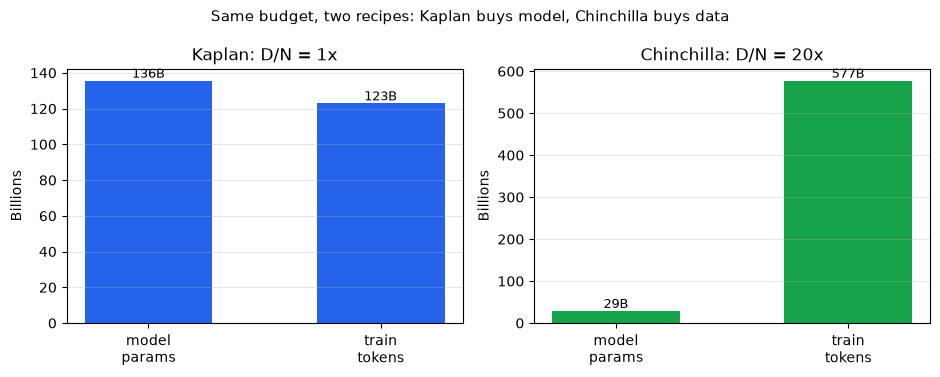

In [3]:
# === 同一笔预算，两个配方各买什么 ===
C = 1e23                              # 约 GPT-3 量级的训练算力
mult = C / C_ref

N_k, D_k = N_ref * mult ** 0.73, D_ref * mult ** 0.27   # Kaplan 配方
N_c, D_c = N_ref * mult ** 0.5,  D_ref * mult ** 0.5    # Chinchilla 配方

print(f"计算预算: {C:.0e} FLOPs")
print()
print(f"{'配方':<12s} {'模型':>6s} {'数据':>13s} {'D/N':>6s}")
print("-" * 42)
print(f"{'Kaplan':<12s} {N_k/1e9:>4.0f}B {D_k/1e9:>8.0f}B tok {D_k/N_k:>5.1f}x")
print(f"{'Chinchilla':<12s} {N_c/1e9:>4.0f}B {D_c/1e9:>8.0f}B tok {D_c/N_c:>5.1f}x")
print()
print("关键观察：")
print(f"  1. Kaplan 的模型大 {N_k/N_c:.1f} 倍，数据只有 Chinchilla 的 {D_k/D_c*100:.0f}%")
print("  2. 实测 loss：Chinchilla 配方更低，Kaplan 的配比被推翻")

# 并排画出来：同一笔钱，两种买法的差别一眼可见
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
recipes = [
    ('Kaplan',   N_k, D_k, '#2563eb'),
    ('Chinchilla', N_c, D_c, '#16a34a'),
]
for ax, (name, N, D, color) in zip(axes, recipes):
    bars = ax.bar(['model\nparams', 'train\ntokens'],
                  [N / 1e9, D / 1e9], color=color, width=0.55)
    ax.bar_label(bars, fmt='%.0fB', fontsize=9)
    ax.set_title(f'{name}: D/N = {D/N:.0f}x')
    ax.set_ylabel('Billions')
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle('Same budget, two recipes: Kaplan buys model, Chinchilla buys data',
             fontsize=11)
plt.tight_layout()
plt.show()


### 3.3 Gopher 与 Chinchilla

DeepMind 用两个配方各训了一个模型，训练算力完全相同：

| 模型 | 参数量 | 训练数据 | 配方 |
|:---|:---|:---|:---|
| Gopher | 280B | 300B tokens | Kaplan 式：大模型、少数据 |
| Chinchilla | 70B | 1.4T tokens | 新配方：小一圈、数据多 4.7 倍 |

结果：Chinchilla 在几乎所有基准上超过 Gopher。参数少 4 倍，效果反而更好。

这一下把行业打醒了：2020 到 2022 年间按 Kaplan 配方训的大模型，大概率都「没喂饱」。

## 4. LLaMA 与过度训练

Chinchilla 的「最优」有一个前提：只优化训练这一次的成本。但模型训完是要上线的——服务百万用户时，推理花的钱往往远超训练。而推理成本主要由参数量决定：模型小一号，每次调用都便宜一点。

于是 2023 年之后的配方变了：故意选一个比 Chinchilla 最优更小的模型，把 token 喂到远超 20 倍。训练多花的钱，从推理里成倍省回来。这就是「过度训练」（over-training），本质是把优化目标从「训练最优」换成了「训练 + 推理总账最优」。

一个极端例子是 LLaMA 3 8B：按 Chinchilla 配方它只需要 8B × 20 = 160B tokens，实际喂了 15T，是「最优」的 94 倍。换来的是这个 8B 模型的能力远超同尺寸的预期，而推理成本只有 70B 模型的九分之一左右。

模型                       参数   tokens     D/N
----------------------------------------------
GPT-3 (2020)           175B    300B    1.7x
Chinchilla (2022)       70B   1400B   20.0x
LLaMA 7B (2023)          7B   1000B  142.9x
LLaMA 2 7B (2023)        7B   2000B  285.7x
LLaMA 3 8B (2024)        8B  15000B 1875.0x
LLaMA 3 70B (2024)      70B  15000B  214.3x
DeepSeek-V2 (2024)     236B   8100B   34.3x

关键观察：
  1. 2020 年 GPT-3 每个参数只看 1.7 个 token，明显「饿着」
  2. 2024 年 8B 模型每个参数看 1875 个 token，是 Chinchilla 最优的 94 倍
  3. LLaMA 3 的 8B 和 70B 用的都是 15T：同一份数据喂所有尺寸，
     越小的模型「过量」越狠——推理越便宜的尺寸越往饱里喂

注：DeepSeek-V2 是 MoE，236B 是总参数；按 21B 激活参数算是 386x


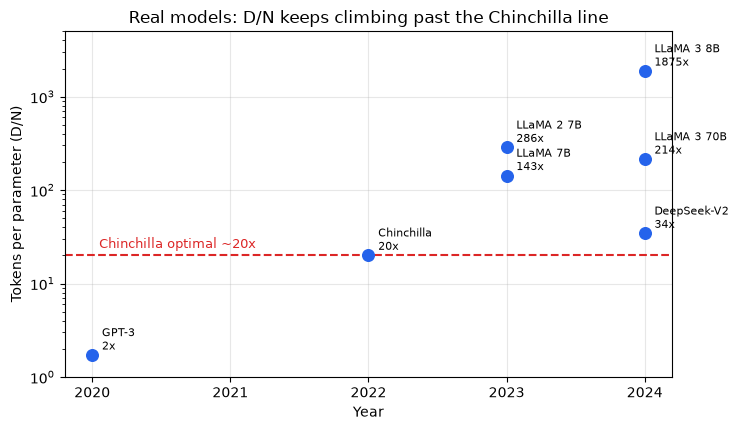

In [4]:
# === 真实模型的 D/N：行业早已越过 20 ===
models = [
    ("GPT-3 (2020)",       175,   300),
    ("Chinchilla (2022)",   70,  1400),
    ("LLaMA 7B (2023)",      7,  1000),
    ("LLaMA 2 7B (2023)",    7,  2000),
    ("LLaMA 3 8B (2024)",    8, 15000),
    ("LLaMA 3 70B (2024)",  70, 15000),
    ("DeepSeek-V2 (2024)", 236,  8100),
]

print(f"{'模型':<20s} {'参数':>6s} {'tokens':>8s} {'D/N':>7s}")
print("-" * 46)
for name, p, d in models:
    print(f"{name:<20s} {p:>5d}B {d:>6d}B {d/p:>6.1f}x")

print()
print("关键观察：")
print("  1. 2020 年 GPT-3 每个参数只看 1.7 个 token，明显「饿着」")
print("  2. 2024 年 8B 模型每个参数看 1875 个 token，是 Chinchilla 最优的 94 倍")
print("  3. LLaMA 3 的 8B 和 70B 用的都是 15T：同一份数据喂所有尺寸，")
print("     越小的模型「过量」越狠——推理越便宜的尺寸越往饱里喂")
print()
print("注：DeepSeek-V2 是 MoE，236B 是总参数；按 21B 激活参数算是 386x")

# 按年份画散点：D/N 从 2 冲到 1875，早就越过了 20 这条「最优线」
import matplotlib.pyplot as plt

years = [int(n.split('(')[1][:-1]) for n, p, d in models]
dn = [d / p for n, p, d in models]

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.scatter(years, dn, s=70, color='#2563eb', zorder=3)
for (name, p, d), y, r in zip(models, years, dn):
    short = name.split(' (')[0]
    ax.annotate(f"{short}\n{d/p:.0f}x", (y, r), textcoords="offset points",
                xytext=(7, 4), fontsize=8)
ax.axhline(20, color='#dc2626', linestyle='--', linewidth=1.5)
ax.text(2020.05, 24, 'Chinchilla optimal ~20x', color='#dc2626', fontsize=9)
ax.set_yscale('log')
ax.set_ylim(1, 5000)
ax.set_xlabel('Year')
ax.set_ylabel('Tokens per parameter (D/N)')
ax.set_title('Real models: D/N keeps climbing past the Chinchilla line')
ax.set_xticks([2020, 2021, 2022, 2023, 2024])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. µP 与超参数迁移

训练一个 70B 模型之前，还得先定学习率、初始化方差这些超参。在 70B 上做网格搜索不现实，跑一轮就是几十万美元。通行做法是「代理调参」：在 1% 大小的模型上扫超参，把最好的搬上去。

问题在于，搬过去经常失灵：10M 上最优的学习率，到 7B 上可能直接把训练打发散。直觉原因在宽度：层变宽之后，一次前向的激活值、一次反向的梯度量级都会漂移，合适的步长自然跟着变。超参并不是「模型无关」的。

µP（Maximal Update Parameterization，Tensor Programs V，2022）解决的就是这个。它给不同位置的权重矩阵规定了「随宽度怎么缩放」的初始化方差和学习率，让每一步更新对输出造成的影响不随宽度变化，小模型和大模型的训练手感一致。于是小模型上扫出的最优学习率可以零样本迁移到大模型，调参的算力开销砍掉好几个数量级。

工程上不需要手推这些指数：microsoft/mup 库把缩放规则封装好了，Cerebras 等训练框架也内置了 µP 选项。迁移之后仍建议在大模型上小范围验证——µP 提高的是迁移成功率，不是保证。

 宽度 fan_in       N(0,1) 的输出 std      N(0,1/fan_in) 的输出 std
------------------------------------------------------------
        64                  7.9                      0.979
       256                 16.2                      1.011


      1024                 32.3                      0.978
      4096                 64.5                      0.999


     16384                129.4                      0.997

关键观察：
  1. 方差不缩放时，宽度 ×64，输出 std 跟着 ×8（根号关系）——激活量级漂了
  2. 方差取 1/fan_in 时，输出 std 稳在 1 附近——这就是缩放规则守住的量级
  3. µP 把「初始化方差 + 学习率」两套缩放一起配好，
     让宽度和最优超参解耦，小模型的调参结果才搬得上去


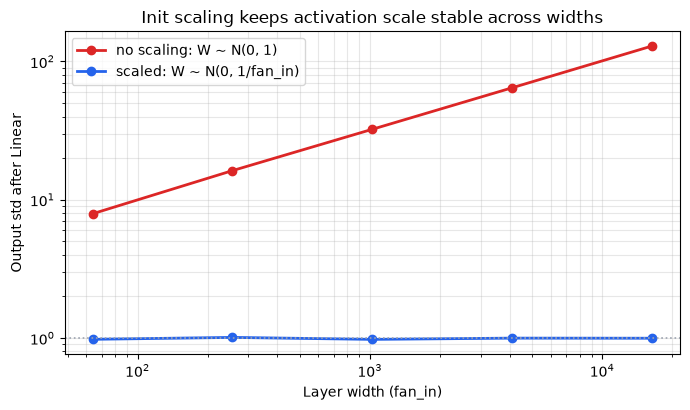

In [5]:
# === 手感为什么随宽度漂移：先看激活值 ===
import numpy as np

rng = np.random.default_rng(42)

widths = [64, 256, 1024, 4096, 16384]
std_naive = []
std_scaled = []

print(f"{'宽度 fan_in':>10s} {'N(0,1) 的输出 std':>20s} {'N(0,1/fan_in) 的输出 std':>26s}")
print("-" * 60)
for width in widths:
    x = rng.normal(size=width)                      # 输入维度 = 层宽
    x = x / x.std()                                 # 固定经验方差为 1，方便对照理论值
    W_naive = rng.normal(0, 1.0, (1024, width))     # 方差不随宽度缩放
    W_scaled = rng.normal(0, width ** -0.5, (1024, width))  # 方差 = 1/fan_in
    s1 = (W_naive * x).sum(axis=1).std()
    s2 = (W_scaled * x).sum(axis=1).std()
    std_naive.append(s1)
    std_scaled.append(s2)
    print(f"{width:>10d} {s1:>20.1f} {s2:>26.3f}")

print()
print("关键观察：")
print("  1. 方差不缩放时，宽度 ×64，输出 std 跟着 ×8（根号关系）——激活量级漂了")
print("  2. 方差取 1/fan_in 时，输出 std 稳在 1 附近——这就是缩放规则守住的量级")
print("  3. µP 把「初始化方差 + 学习率」两套缩放一起配好，")
print("     让宽度和最优超参解耦，小模型的调参结果才搬得上去")

# 画成两条曲线：不缩放的一路飞，缩放的稳在 1
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(widths, std_naive, 'o-', color='#dc2626', linewidth=2,
        label='no scaling: W ~ N(0, 1)')
ax.plot(widths, std_scaled, 'o-', color='#2563eb', linewidth=2,
        label='scaled: W ~ N(0, 1/fan_in)')
ax.axhline(1.0, color='#9ca3af', linestyle=':', linewidth=1.2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Layer width (fan_in)')
ax.set_ylabel('Output std after Linear')
ax.set_title('Init scaling keeps activation scale stable across widths')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


## 6. 训练 FLOPs

配方定了，接下来问：这一趟训练要花多少算力？答案是一个乘法：

$$C \approx 6 \cdot N \cdot D$$

C 是总计算量（FLOPs），N 是参数量，D 是训练 token 数。系数 6 的来历可以手算：

- Forward：模型主体是一堆权重矩阵乘法。每处理一个 token，每个参数大约参与一次乘加，一次乘加算 2 FLOPs，所以 forward ≈ 2N FLOPs/token；
- Backward：反向要同时算「对输入的梯度」和「对权重的梯度」，量级约是 forward 的两倍 ≈ 4N FLOPs/token；
- 合计 2N + 4N = 6N FLOPs/token，训 D 个 token 就是 6ND。

Attention 分数、embedding 查表这些开销是次一级的项，工程估算里都吸进「≈」里。逐层精确的账放在附录 B，这里的 6ND 是规划用的第一级近似。

In [6]:
# === FLOPs 手算：LLaMA 7B + 1T tokens ===
N = 7e9        # 7B 参数
D = 1e12       # 1T tokens

flops_per_token = 6 * N
total_flops = flops_per_token * D

print(f"每个 token: 6 × {N:.1e} = {flops_per_token:.1e} FLOPs")
print(f"总共 {D:.0e} 个 token: {total_flops:.1e} FLOPs")
print()
print("关键观察：")
print(f"  1. 7B 模型每处理一个 token 要做 {flops_per_token/1e9:.0f}B 次运算")
print(f"  2. 一条 1000 token 的样本就是 {flops_per_token * 1000 / 1e12:.0f} TFLOPs")
print("  3. 这个量级没法直观感受，下一节换算成 GPU 和天数")

每个 token: 6 × 7.0e+09 = 4.2e+10 FLOPs
总共 1e+12 个 token: 4.2e+22 FLOPs

关键观察：
  1. 7B 模型每处理一个 token 要做 42B 次运算
  2. 一条 1000 token 的样本就是 42 TFLOPs
  3. 这个量级没法直观感受，下一节换算成 GPU 和天数


## 7. 训练时间与成本

FLOPs 太抽象，工程上换一个单位：GPU-hours，一张卡满负荷跑一小时。换算公式：

```
GPU-hours = 总 FLOPs ÷ (单卡有效算力 × 3600)
```

「有效算力」不等于硬件标称的峰值。通信等待、数据加载、显存碎片都会让 GPU 吃不满，实际利用率（MFU，Model FLOPs Utilization）通常在 40% 到 60% 之间。不同卡的峰值、利用率和租金都不同，先看清楚再算钱。

In [7]:
# === 常见训练卡的有效算力（示例估算） ===
# 时租随地区、供需、租期变化很快，这里的数字只为演示算法。
# 写作日期 2026-08，真实预算请按当日报价重算。
gpus = [
    ("A100 80GB",  312, 0.50, 2.0),   # (名称, 峰值TFLOPS, 利用率, 示例时租$/h)
    ("H100 80GB",  990, 0.50, 3.5),
    ("H200 141GB", 990, 0.50, 4.5),
    ("RTX 4090",   165, 0.40, 0.5),
]

print(f"{'GPU':<14s} {'峰值':>6s} {'利用率':>6s} {'有效算力':>8s} {'示例时租':>8s}")
print("-" * 48)
for name, peak, util, price in gpus:
    print(f"{name:<14s} {peak:>4d}TF {util*100:>5.0f}% {peak*util:>6.0f}TF"
          f"   ${price:.1f}/h")

print()
print("关键观察：H100 的有效算力约是 A100 的 3 倍，时租不到 2 倍，")
print("          预算够时租 H 系列反而更划算（还要看互联和显存）。")

GPU                峰值    利用率     有效算力     示例时租
------------------------------------------------
A100 80GB       312TF    50%    156TF   $2.0/h
H100 80GB       990TF    50%    495TF   $3.5/h
H200 141GB      990TF    50%    495TF   $4.5/h
RTX 4090        165TF    40%     66TF   $0.5/h

关键观察：H100 的有效算力约是 A100 的 3 倍，时租不到 2 倍，
          预算够时租 H 系列反而更划算（还要看互联和显存）。


In [8]:
# === GPU-hours 手算：LLaMA 7B + 1T tokens ===
total_flops = 6 * 7e9 * 1e12

print(f"总 FLOPs = {total_flops:.1e}")
print()
print(f"{'GPU':<14s} {'GPU-hours':>12s} {'单卡天数':>10s} {'256 卡天数':>10s}")
print("-" * 52)
for name, peak, util, price in gpus:
    eff = peak * util                       # 有效算力，TFLOPS
    hours = total_flops / (eff * 1e12 * 3600)
    print(f"{name:<14s} {hours:>12,.0f} {hours/24:>10,.0f} {hours/256/24:>10.1f}")

print()
print("关键观察：")
print("  1. GPU-hours 只跟总算力有关，跟几张卡无关：")
print("     256 卡跑 1 天 ≈ 1 卡跑 256 天，是同一个数字")
print("  2. 多加卡买到的是时间，不是总计算量")

总 FLOPs = 4.2e+22

GPU               GPU-hours       单卡天数    256 卡天数
----------------------------------------------------
A100 80GB            74,786      3,116       12.2
H100 80GB            23,569        982        3.8
H200 141GB           23,569        982        3.8
RTX 4090            176,768      7,365       28.8

关键观察：
  1. GPU-hours 只跟总算力有关，跟几张卡无关：
     256 卡跑 1 天 ≈ 1 卡跑 256 天，是同一个数字
  2. 多加卡买到的是时间，不是总计算量


模型                          参数  tokens    FLOPs   GPU-hours   2048卡·天     成本
------------------------------------------------------------------------------
GPT-3 175B                175B   300B  3.2e+23     560,897      11.4 $  1.1M
Chinchilla 70B             70B  1400B  5.9e+23   1,047,009      21.3 $  2.1M
LLaMA 2 70B                70B  2000B  8.4e+23   1,495,726      30.4 $  3.0M
LLaMA 3 8B                  8B 15000B  7.2e+23   1,282,051      26.1 $  2.6M
LLaMA 3 70B                70B 15000B  6.3e+24  11,217,949     228.2 $ 22.4M
DeepSeek-V3 (37B 激活)       37B 14800B  3.3e+24   5,850,427     119.0 $ 11.7M

计算口径: GPU-hours = FLOPs ÷ (156 TFLOPS × 3600)，成本 = GPU-hours × $2
关键观察：
  1. DeepSeek-V3 是 MoE：6ND 里的 N 用激活参数 37B，不是总参数 671B
  2. 这是单次训练的下限；失败重跑、评测、消融都会往上加


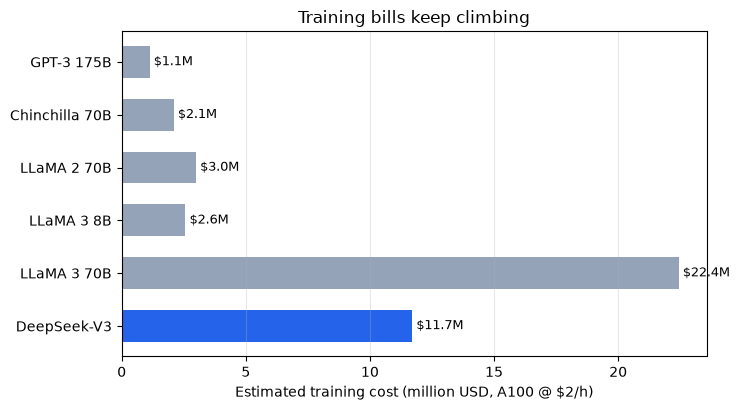

In [9]:
# === 主流模型的训练账单 + 可视化（A100 口径估算） ===
a100_eff = 312 * 0.5        # A100 有效算力 156 TFLOPS
a100_price = 2.0            # 示例时租 $2/h

models = [
    ("GPT-3 175B",           175e9,  300e9),
    ("Chinchilla 70B",        70e9, 1400e9),
    ("LLaMA 2 70B",           70e9, 2000e9),
    ("LLaMA 3 8B",             8e9,   15e12),
    ("LLaMA 3 70B",           70e9,   15e12),
    ("DeepSeek-V3 (37B 激活)", 37e9, 14.8e12),
]

print(f"{'模型':<24s} {'参数':>5s} {'tokens':>7s} {'FLOPs':>8s} "
      f"{'GPU-hours':>11s} {'2048卡·天':>9s} {'成本':>6s}")
print("-" * 78)
costs_musd = []
names = []
for name, p, d in models:
    flops = 6 * p * d
    hours = flops / (a100_eff * 1e12 * 3600)
    cost_m = hours * a100_price / 1e6
    costs_musd.append(cost_m)
    names.append(name.split(' (')[0] if '激活' in name else name)
    print(f"{name:<24s} {p/1e9:>4.0f}B {d/1e9:>5.0f}B {flops:>8.1e} "
          f"{hours:>11,.0f} {hours/2048/24:>9.1f} ${cost_m:>5.1f}M")

print()
print("计算口径: GPU-hours = FLOPs ÷ (156 TFLOPS × 3600)，成本 = GPU-hours × $2")
print("关键观察：")
print("  1. DeepSeek-V3 是 MoE：6ND 里的 N 用激活参数 37B，不是总参数 671B")
print("  2. 这是单次训练的下限；失败重跑、评测、消融都会往上加")

# 训练成本画成条形图：四年之内，账单从 $4M 涨到 $50M+
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 4.2))
colors = ['#94a3b8'] * len(names)
colors[-1] = '#2563eb'
bars = ax.barh(names[::-1], costs_musd[::-1], color=colors[::-1], height=0.6)
ax.bar_label(bars, fmt='$%.1fM', fontsize=9, padding=3)
ax.set_xlabel('Estimated training cost (million USD, A100 @ $2/h)')
ax.set_title('Training bills keep climbing')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 8. 训练显存

预算够还不行，参数得先住进显存。AdamW + 混合精度的全量训练里，每个参数要养活一大家子（分布式训练一节算过这笔账）：

```
① 参数 (FP16/BF16)         2 bytes × P
② 梯度 (FP16/BF16)         2 bytes × P
③ Adam 一阶矩 m (FP32)      4 bytes × P
④ Adam 二阶矩 v (FP32)      4 bytes × P
⑤ FP32 master 权重          4 bytes × P
──────────────────────────────────────
固定开销                    16 bytes × P
⑥ 激活值                    随 batch、seq_len、层数浮动
```

经验法则：全量训练按 **20 bytes/参数** 预留（16 份固定开销 + 激活值的粗略份额）。7B 就是约 140 GB，单张 A100 80GB 装不下，全量训练 7B 起步就得组多卡。

In [10]:
# === 显存手算：全量训练按 20 bytes/参数预留 ===
P = 7e9

parts = [
    ("参数 (FP16/BF16)",   2 * P),
    ("梯度 (FP16/BF16)",   2 * P),
    ("Adam m (FP32)",      4 * P),
    ("Adam v (FP32)",      4 * P),
    ("master 权重 (FP32)", 4 * P),
]
fixed = sum(n_bytes for _, n_bytes in parts)

print("7B 模型的固定开销：")
for name, n_bytes in parts:
    print(f"  {name:<20s} {n_bytes/1e9:>6.1f} GB")
print(f"  {'小计':<20s} {fixed/1e9:>6.1f} GB (= 16 × P bytes)")
print()

print(f"{'模型':<8s} {'固定开销':>9s} {'含激活粗估':>10s} {'A100 80G':>9s}")
print("-" * 42)
for name, p in [("1.5B", 1.5e9), ("7B", 7e9), ("13B", 13e9),
                ("70B", 70e9), ("175B", 175e9)]:
    fixed_i, total_i = 16 * p, 20 * p
    print(f"{name:<8s} {fixed_i/1e9:>7.0f} GB {total_i/1e9:>7.0f} GB"
          f" {total_i/80e9:>7.1f} 张")

print()
print("关键观察：")
print("  1. 权重本身只占 2/16，剩下 14 份是梯度和优化器状态")
print("  2. 20 bytes/参数是 AdamW 全量训练的粗略起点，")
print("     ZeRO/FSDP 切分、8-bit 优化器、激活重计算都会改写它")
print("  3. 推理没有梯度和优化器，显存主要是权重 + KV Cache，别套这个表")

7B 模型的固定开销：
  参数 (FP16/BF16)         14.0 GB
  梯度 (FP16/BF16)         14.0 GB
  Adam m (FP32)          28.0 GB
  Adam v (FP32)          28.0 GB
  master 权重 (FP32)       28.0 GB
  小计                    112.0 GB (= 16 × P bytes)

模型            固定开销      含激活粗估  A100 80G
------------------------------------------
1.5B          24 GB      30 GB     0.4 张
7B           112 GB     140 GB     1.8 张
13B          208 GB     260 GB     3.2 张
70B         1120 GB    1400 GB    17.5 张
175B        2800 GB    3500 GB    43.8 张

关键观察：
  1. 权重本身只占 2/16，剩下 14 份是梯度和优化器状态
  2. 20 bytes/参数是 AdamW 全量训练的粗略起点，
     ZeRO/FSDP 切分、8-bit 优化器、激活重计算都会改写它
  3. 推理没有梯度和优化器，显存主要是权重 + KV Cache，别套这个表


## 9. 三种 Scaling 范式的比较

| 年份 | 配方 | 最优配比 | 代表模型 | 优化目标 |
|:---|:---|:---|:---|:---|
| 2020 · Kaplan | 优先加大模型 | N ∝ C^0.73，D ∝ C^0.27 | GPT-3 175B + 300B tok（D/N ≈ 1.7） | 训练 loss |
| 2022 · Chinchilla | 模型数据并重 | N ∝ C^0.5，D ∝ C^0.5，D/N ≈ 20 | Chinchilla 70B + 1.4T tok | 训练 loss |
| 2023+ · LLaMA | 小模型狂喂 token | D/N 远大于 20，可到 1000+ | LLaMA 3 8B + 15T tok（D/N ≈ 1875） | 推理成本 |

注意被优化的目标一直在变：Kaplan 和 Chinchilla 争的是「训练算力怎么花最值」，LLaMA 把账本换成了「训练 + 推理的总账」。三个结论都没有错，只是回答的问题不一样。

## 小结

- [ ] 幂律：Loss ≈ a·N^(-b) + c，可约部分每扩大 10 倍缩到 10^(-b)，收益递减
- [ ] Kaplan（2020）：N ∝ C^0.73、D ∝ C^0.27，预算优先投入模型
- [ ] Chinchilla（2022）：N、D 各 ∝ C^0.5，每个参数约配 20 个 token
- [ ] 过度训练（2023+）：推理成本主导，小模型配以更多 token 更划算
- [ ] µP：宽度缩放规则让超参可迁移，调参无需在大模型上反复试验
- [ ] FLOPs：C ≈ 6ND（forward 2N + backward 4N，每 token）
- [ ] GPU-hours = FLOPs ÷ (有效算力 × 3600)，与用几张卡无关
- [ ] 显存：AdamW 全量训练约 16-20 bytes/参数，7B 起步就是百 GB 级

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：把 FLOPs 换算成 PFLOPs-days**

训练 LLaMA 7B 用了 1T（$10^{12}$）tokens。用 $C \approx 6ND$ 算出总 FLOPs，再换算成 PFLOPs-days（1 PFLOPs-day = $10^{15} \times 86400$ FLOPs）。

小提示：先算 $6 \times 7 \times 10^{9} \times 10^{12}$，再除以 $8.64 \times 10^{19}$。

In [11]:
# 作业 1：FLOPs → PFLOPs-days
N = 7e9      # 7B 参数
D = 1e12     # 1T tokens

# TODO: 计算总 FLOPs（C ≈ 6ND）
total_flops = None

# TODO: 换算成 PFLOPs-days（1 PFLOPs-day = 1e15 × 86400 FLOPs）
pflops_days = None

# 填完后取消下面的注释运行检查
# assert total_flops == 6 * N * D
# assert abs(pflops_days - 6 * N * D / (1e15 * 86400)) < 0.01
# print(f"✅ 作业 1 通过：{pflops_days:.0f} PFLOPs-days")
# print("   相当于 2048 张 A100（有效 156 TFLOPS）满负荷跑约 1.5 天。")

**作业 2：预算翻倍，模型各长多大**

计算预算翻倍时，Kaplan（$N \propto C^{0.73}$）和 Chinchilla（$N \propto C^{0.5}$）各自的模型参数量增长到原来的多少倍。

小提示：$N_{new}/N_{old} = 2^{\text{指数}}$。

In [12]:
# 作业 2：预算翻倍时的模型增长倍数
ratio = 2    # 预算翻倍

# TODO: Kaplan 下模型增长倍数（N ∝ C^0.73）
kaplan_ratio = None

# TODO: Chinchilla 下模型增长倍数（N ∝ C^0.5）
chinchilla_ratio = None

# 填完后取消下面的注释运行检查
# assert abs(kaplan_ratio - 2 ** 0.73) < 0.01
# assert abs(chinchilla_ratio - 2 ** 0.5) < 0.01
# print(f"✅ 作业 2 通过：Kaplan ×{kaplan_ratio:.2f}，Chinchilla ×{chinchilla_ratio:.2f}")
# print("   同样翻倍的预算，Kaplan 更愿意把钱花在加大模型上。")

**作业 3：7B 全量训练的固定显存**

AdamW + 混合精度下：参数（FP16）2 bytes、梯度（FP16）2 bytes、Adam 的 m 和 v（FP32）各 4 bytes、master 权重（FP32）4 bytes。算出 7B 模型的固定开销是多少 GB。

小提示：每参数 16 bytes，乘以 $7 \times 10^{9}$ 再换算单位。

In [13]:
# 作业 3：7B 全量训练的固定显存
P = 7e9

# TODO: 固定开销合计（bytes）：2P + 2P + 4P + 4P + 4P
fixed_bytes = None

# TODO: 换算成 GB
fixed_gb = None

# 填完后取消下面的注释运行检查
# assert fixed_bytes == 16 * P
# assert abs(fixed_gb - 16 * P / 1e9) < 0.1
# print(f"✅ 作业 3 通过：固定开销 {fixed_gb:.0f} GB")
# print("   权重本身只占 14 GB，剩下 98 GB 是梯度和优化器状态，")
# print("   这就是 7B 模型塞不进单张 A100 80GB 的原因。")

## 参考资料

- Kaplan et al., [Scaling Laws for Neural Language Models](https://arxiv.org/abs/2001.08361), 2020 — 「优先增大模型」的原始论文
- Hoffmann et al., [Training Compute-Optimal Large Language Models](https://arxiv.org/abs/2203.15556), 2022 — Chinchilla：模型和数据并重
- Yang et al., [Tensor Programs V: Tuning Large Neural Networks via Zero-Shot Hyperparameter Transfer](https://arxiv.org/abs/2203.03466), 2022 — µP 超参迁移
- Meta, [The Llama 3 Herd of Models](https://arxiv.org/abs/2407.21783), 2024 — 8B/70B 都用 15T tokens 的过度训练实践
- [microsoft/mup](https://github.com/microsoft/mup) — µP 的参考实现